In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##**Importando librerías y dataset**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

data_path = "15_pokemon.csv"
data = pd.read_csv(data_path)

In [3]:
data.head(10)

,pokemonID,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False



`two_typed_data` guardará solo los datos de los Pokèmon que tengan 2 Tipos.

`all_data`guardará los datos de todos los Pokèmon

In [4]:
# tratando los NaN

two_typed_data = data.dropna()
all_data = data.fillna("No tiene")
all_data.head(10)

,pokemonID,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,No tiene,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,No tiene,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,No tiene,314,44,48,65,50,64,43,1,False


In [5]:
two_typed_data.head(10)

,pokemonID,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
15,12,Butterfree,Bug,Flying,395,60,45,50,90,80,70,1,False
16,13,Weedle,Bug,Poison,195,40,35,30,20,20,50,1,False
17,14,Kakuna,Bug,Poison,205,45,25,50,25,25,35,1,False


##**Plotting Gráficas**##

<Figure size 640x480 with 0 Axes>

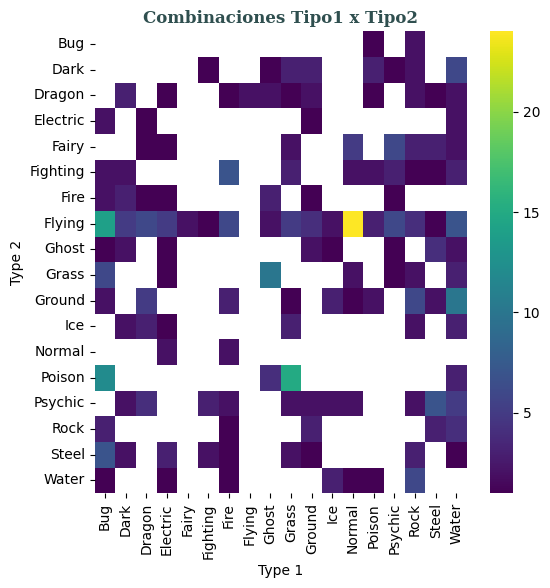

In [6]:
# defino algunas variables con valores que usaré en los plots
color1 = "purple"
color2 = "darkslategray"
color3 = "goldenrod"
family = "serif"

# Ajustar el diseño de la figura para evitar superposiciones
plt.tight_layout()

# Crear una figura de tamaño 6x6 pulgadas para el gráfico
plt.subplots(figsize=(6, 6))

# diagramaq: cuenta las ocurrencias de 'Type 2' para cada valor único de 'Type 1'
# define estos valores para x_label que será usado luego en la gráfica
diagrama = pd.DataFrame({x_label: grp['Type 2'].value_counts() for x_label, grp in two_typed_data.groupby('Type 1')})

# Generar un mapa de calor utilizando Seaborn con la variable diagrama
sns.heatmap(diagrama, cmap='viridis')

# Establecer etiquetas para los ejes x e y en el gráfico
plt.xlabel('Type 1')
plt.ylabel('Type 2')

# Establecer el título del gráfico con propiedades de fuente y color
plt.title("Combinaciones Tipo1 x Tipo2", fontdict={"fontweight": "bold", "family": family}, color = color2)

# Guardar la figura como un archivo de imagen
plt.savefig("combos_t1xt2.png")
plt.show()

<ipython-input-7-c177e7d824b5>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(all_data, x='Total', y='Type 1', inner='stick', palette='Dark2')


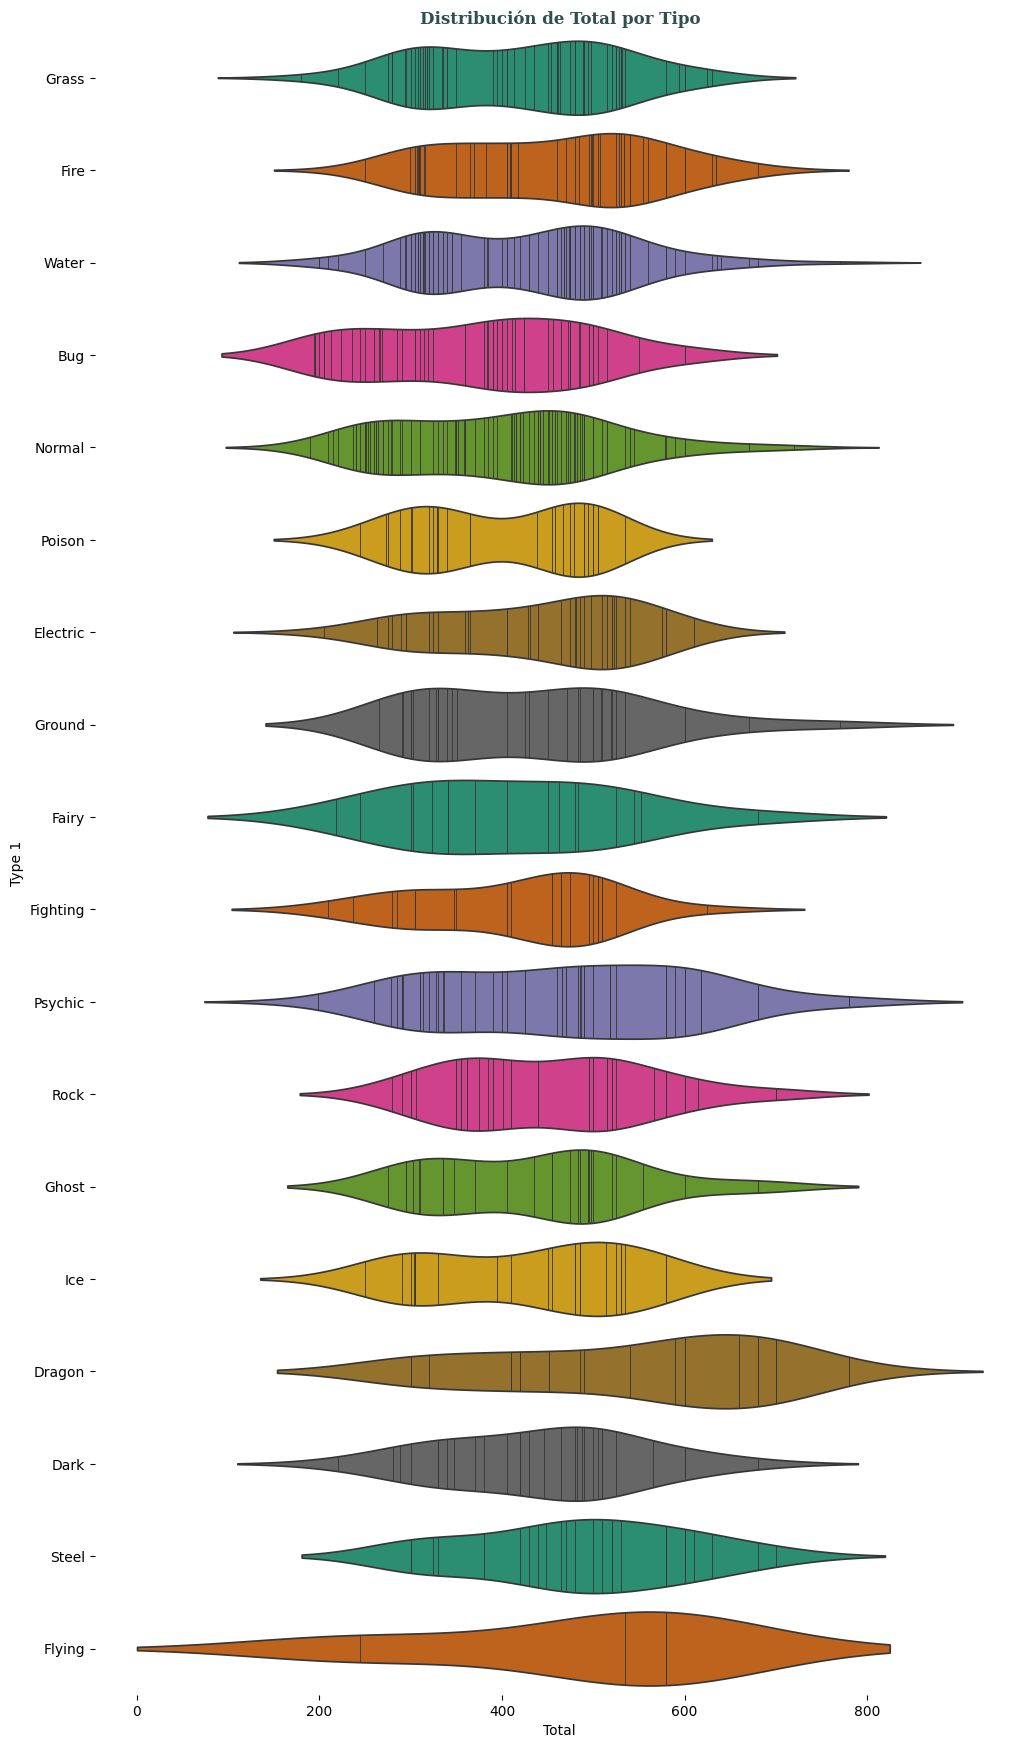

In [7]:
# Calcular el tamaño de la figura en función del número de valores únicos en la columna 'Type 1'
# Así, si el número de tipos a representar cambia, la grafica se ajusta automáticamente
figsize = (12, 1.2 * len(all_data['Type 1'].unique()))
plt.figure(figsize=figsize)

# Crear un gráfico de violín utilizando Seaborn para visualizar la distribución de 'Total' por cada  tipo en 'Type 1'
sns.violinplot(all_data, x='Total', y='Type 1', inner='stick', palette='Dark2')

# Quitar los bordes de la figura
sns.despine(top=True, right=True, bottom=True, left=True)

# Establecer el título del gráfico con propiedades de fuente y color personalizadas con las variables creadas anteriormente
plt.title("Distribución de Total por Tipo", fontdict={"fontweight": "bold", "family": family}, color = color2)

plt.savefig("total_per_type.png")

##**Filtrando y oredenando datos para otras gráficas**##

In [8]:
types1 = list(data["Type 1"].unique())

In [9]:
print(types1)

['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric', 'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice', 'Dragon', 'Dark', 'Steel', 'Flying']


In [10]:
# Definir una función lambda que calcula la media de los valores de 'HP' para un tipo específico ('t') de un Pokèmon cuándo este no tenga 'Type 2'
hp_mean_t1 = lambda data, t: statistics.mean(data.loc[(data["Type 1"] == t) & (data["Type 2"] == "No tiene")]["HP"])

In [11]:
# Aplicando la función para crear la variable 'means_t1' con las medias de HP para cada pokemon que solo tenga un tipo
means_t1 = {t: hp_mean_t1(all_data,t) for t in types1}

In [12]:
means_t1

{'Grass': 64.39393939393939,
 'Fire': 62.714285714285715,
 'Water': 66.84745762711864,
 'Bug': 53.05882352941177,
 'Normal': 81.09836065573771,
 'Poison': 66,
 'Electric': 60,
 'Ground': 64.6923076923077,
 'Fairy': 74.66666666666667,
 'Fighting': 71.15,
 'Psychic': 72.55263157894737,
 'Rock': 67.11111111111111,
 'Ghost': 49.3,
 'Ice': 67.92307692307692,
 'Dragon': 61.81818181818182,
 'Dark': 60.5,
 'Steel': 62,
 'Flying': 79}

In [13]:
# Crea un DataFrame con dos columnas, en una está el tipo del pokemon y en la otra el valor médio de HP para este tipo.
# Despues de crear el DataFrame, se le aplica el método sort_values para ordenar los valore en orden decreciente
means_t1 = pd.DataFrame(data=means_t1.values(),index=means_t1.keys(), columns=["HP Medio"]).sort_values("HP Medio", ascending=False)

<Figure size 640x480 with 0 Axes>

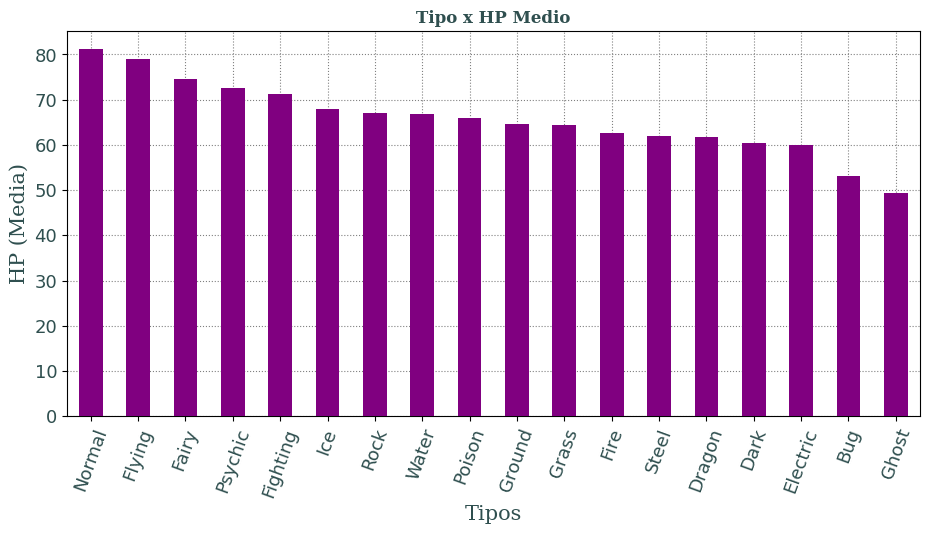

In [14]:
# Ajustar el diseño de la figura para evitar superposiciones
plt.tight_layout()

# Crear una nueva figura con un tamaño específico
plt.figure(figsize=[11,5])

# Graficar los valores de "HP Medio" del DataFrame means_t1 como un gráfico de barras
means_t1["HP Medio"].plot(kind="bar", color = color1, zorder = 3)

# Establecer etiquetas para los ejes x e y
plt.xlabel("Tipos", fontsize = 15, color = color2, fontdict={"family": family})
plt.ylabel("HP (Media)", fontsize = 15, color = color2, fontdict={"family": family})

# Configurar las etiquetas del eje x para que sean más legibles, con rotación de 70 grados
# Si no se hace esta parte, las etiquetas estarían en vertical
plt.xticks(fontsize = 13, color = color2, rotation = 70)
plt.yticks(fontsize = 13, color = color2)

# Establecer el título del gráfico con propiedades de fuente y color personalizadas
plt.title("Tipo x HP Medio", fontdict={"fontweight": "bold", "family": family}, color = color2)

# Agregar una rejilla al gráfico
plt.grid(True, linestyle = ":", color = "gray", zorder = 0)

# Guardar como imagen
plt.savefig("tipo_x_hp_medio.png")
plt.show()

En esta parte se hace lo mismo que antes, pero ahora considerando solo los pokemons con 2 tipos

In [15]:
# Seleccionar solo las columnas "Type 1" y "Type 2" del DataFrame 'two_typed_data' definido al comienzo del notebook
# a la vez elimino filas duplicadas
unique_two_typed_data = two_typed_data[["Type 1", "Type 2"]].drop_duplicates()

In [16]:
# Convertir cada fila del DataFrame 'unique_two_typed_data' en una tupla
# se ignora 'i' que sería el index de cada fila y no nos interesa ese valor
types = [tuple(t) for i,t in unique_two_typed_data.iterrows()]

In [17]:
print(types)

[('Grass', 'Poison'), ('Fire', 'Flying'), ('Fire', 'Dragon'), ('Bug', 'Flying'), ('Bug', 'Poison'), ('Normal', 'Flying'), ('Poison', 'Ground'), ('Normal', 'Fairy'), ('Poison', 'Flying'), ('Bug', 'Grass'), ('Water', 'Fighting'), ('Water', 'Poison'), ('Rock', 'Ground'), ('Water', 'Psychic'), ('Electric', 'Steel'), ('Water', 'Ice'), ('Ghost', 'Poison'), ('Grass', 'Psychic'), ('Ground', 'Rock'), ('Psychic', 'Fairy'), ('Ice', 'Psychic'), ('Water', 'Flying'), ('Water', 'Dark'), ('Rock', 'Water'), ('Rock', 'Flying'), ('Ice', 'Flying'), ('Electric', 'Flying'), ('Dragon', 'Flying'), ('Psychic', 'Fighting'), ('Water', 'Electric'), ('Fairy', 'Flying'), ('Psychic', 'Flying'), ('Electric', 'Dragon'), ('Water', 'Fairy'), ('Grass', 'Flying'), ('Water', 'Ground'), ('Dark', 'Flying'), ('Normal', 'Psychic'), ('Bug', 'Steel'), ('Ground', 'Flying'), ('Steel', 'Ground'), ('Bug', 'Rock'), ('Bug', 'Fighting'), ('Dark', 'Ice'), ('Fire', 'Rock'), ('Ice', 'Ground'), ('Water', 'Rock'), ('Steel', 'Flying'), ('Dar

In [18]:
# Esta funcion lambda hace lo mismo que la función lambda usada anteriormente, pero ahora para pokemons de dos tipos
# Se calcula la media de los valores de 'HP' para una combinación específica de 'Type 1' y 'Type 2' que se encuentre

hp_mean_two_typed = lambda data, t1, t2: statistics.mean(data.loc[(data["Type 1"] == t1) & (data["Type 2"] == t2), ["HP"]]["HP"])

In [19]:
# Se aplica la función para la lista de tuplas con las combinaciones de tipos generadas antes
mean_two_typed = {t: hp_mean_two_typed(data, t[0], t[1]) for t in types}

In [20]:
mean_two_typed

{('Grass', 'Poison'): 64.86666666666666,
 ('Fire', 'Flying'): 82,
 ('Fire', 'Dragon'): 78,
 ('Bug', 'Flying'): 63,
 ('Bug', 'Poison'): 53.75,
 ('Normal', 'Flying'): 62.041666666666664,
 ('Poison', 'Ground'): 85.5,
 ('Normal', 'Fairy'): 99.6,
 ('Poison', 'Flying'): 66.66666666666667,
 ('Bug', 'Grass'): 55,
 ('Water', 'Fighting'): 90.66666666666667,
 ('Water', 'Poison'): 61.666666666666664,
 ('Rock', 'Ground'): 55,
 ('Water', 'Psychic'): 87,
 ('Electric', 'Steel'): 48.333333333333336,
 ('Water', 'Ice'): 90,
 ('Ghost', 'Poison'): 48.75,
 ('Grass', 'Psychic'): 77.5,
 ('Ground', 'Rock'): 100,
 ('Psychic', 'Fairy'): 43.666666666666664,
 ('Ice', 'Psychic'): 55,
 ('Water', 'Flying'): 63.142857142857146,
 ('Water', 'Dark'): 69.16666666666667,
 ('Rock', 'Water'): 51.5,
 ('Rock', 'Flying'): 72.5,
 ('Ice', 'Flying'): 67.5,
 ('Electric', 'Flying'): 70.6,
 ('Dragon', 'Flying'): 94.33333333333333,
 ('Psychic', 'Fighting'): 80.66666666666667,
 ('Water', 'Electric'): 100,
 ('Fairy', 'Flying'): 70,
 ('P

In [21]:
# Obtener los valores del diccionario 'mean_two_typed' y convertirlos en una lista
values = list(mean_two_typed.values())

# Ordenar los valores en orden descendente
values.sort(reverse = True)

# Seleccionar los 10 valores más grandes
greatest_10 = values[0:10]

print(greatest_10)

[150, 125, 120, 110, 109, 100, 100, 100, 100, 100]


In [22]:
# Aqui decido quedarme solo con los 10 valores más grandes para representarlos en el plot
# En la celda anterior se obtenia los 10 valores más grandes en las medias, ahora en esta parte se identifica cuales son
# los tipos que corresponden a estos valopres.

# Lo que se hace es buscar en el diccionario cuales claves están asociadas a los 10 valores más grandes encontrados anteriormente

greatest = dict()
i = 0
while i < len(greatest_10):
  enc = False
  j = 0
  while j < len(mean_two_typed) and not enc and i < len(greatest_10):
    k = list(mean_two_typed.keys())
    if mean_two_typed[k[j]] == greatest_10[i]:
      greatest[k[j]] = greatest_10[i]
      mean_two_typed.pop(k[j])
      enc = True
    else:
      j += 1
  i += 1

In [23]:
greatest

{('Ghost', 'Dragon'): 150,
 ('Dragon', 'Ice'): 125,
 ('Ghost', 'Flying'): 120,
 ('Ground', 'Steel'): 110,
 ('Ground', 'Electric'): 109,
 ('Ground', 'Rock'): 100,
 ('Water', 'Electric'): 100,
 ('Rock', 'Dark'): 100,
 ('Psychic', 'Grass'): 100,
 ('Ground', 'Fire'): 100}

In [24]:
df = pd.DataFrame(greatest.values(), index=greatest.keys(), columns=['HP Mean'])

<Figure size 640x480 with 0 Axes>

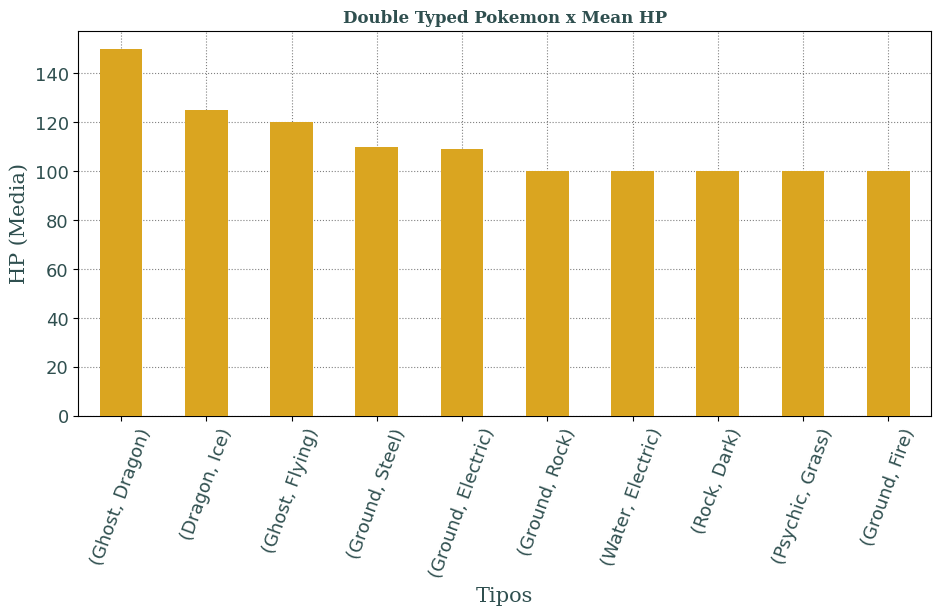

<Figure size 640x480 with 0 Axes>

In [25]:
# Ajustar el diseño
plt.tight_layout()

# Crear una figura con un tamaño específico
plt.figure(figsize=[11,5])

# Graficar la media de HP ("HP Mean") del DataFrame 'df' como un gráfico de barras
df["HP Mean"].plot(kind="bar", color = color3, zorder = 3)

# Establecer etiquetas para los ejes x e y
plt.xlabel("Tipos", fontsize=15, color = color2, fontdict={"family": family})
plt.ylabel("HP (Media)", fontsize=15, color = color2, fontdict={"family": family})

# Configurar las etiquetas del eje x para que sean más legibles
plt.xticks(fontsize = 13, color = color2, rotation = 70)
plt.yticks(fontsize = 13, color = color2)

# Establecer el título del gráfico con propiedades de fuente y color personalizadas
plt.title("Double Typed Pokemon x Mean HP", fontdict={"fontweight": "bold", "family": family}, color = color2)

# Agrega rejilla al gráfico
plt.grid(True, linestyle = ":", color = "gray", zorder= 0)

plt.show()

# Guardar la figura
plt.savefig("pokemon_tipo_doble_X_hp_medio.png")